In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Task 1: Bar Chart 

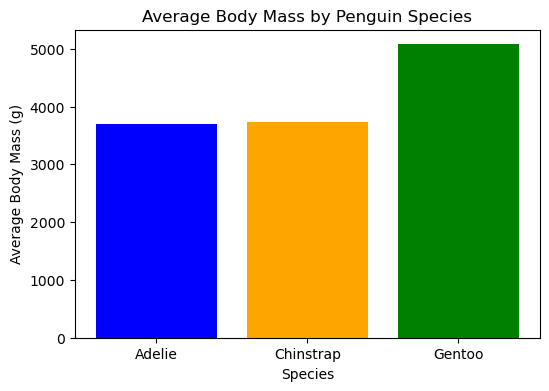

In [20]:
avg_mass = df.groupby('species')['body_mass_g'].mean()
plt.figure(figsize=(6,4))
plt.bar(avg_mass.index, avg_mass.values, color=['blue','orange','green'])
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.title('Average Body Mass by Penguin Species')
plt.show()

## Task 2: Count Plot 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19084\1902727668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species', palette=['blue','red','green'])


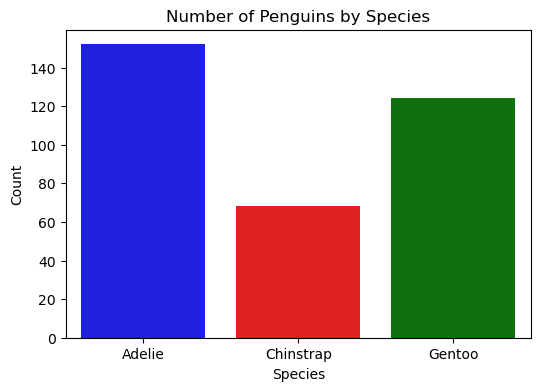

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='species', palette=['blue','red','green'])
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Number of Penguins by Species')
plt.show()
print(df['species'].value_counts())

## Task 3: Histogram 

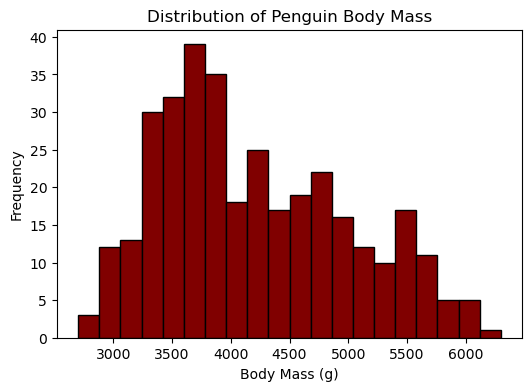

Shape: Slightly Right-skewed (long tail toward higher masses)


In [25]:
plt.figure(figsize=(6,4))
plt.hist(df['body_mass_g'].dropna(), bins=20, edgecolor='black', color='maroon')
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.title('Distribution of Penguin Body Mass')
plt.show()
print('Shape: Slightly Right-skewed (long tail toward higher masses)')

## Task 4: Box Plot 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19084\3581707152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='body_mass_g', palette=['lightblue','pink','green'])


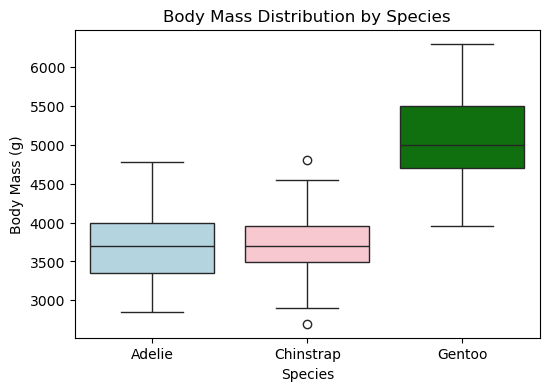

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='species', y='body_mass_g', palette=['lightblue','pink','green'])
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.title('Body Mass Distribution by Species')
plt.show()

## Task 5: Outlier Detection 

In [23]:
col = 'body_mass_g'
data = df[col].dropna()
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = df[(df[col] < lower) | (df[col] > upper)]
print(f'Q1: {Q1:.1f}, Q3: {Q3:.1f}, IQR: {IQR:.1f}')
print(f'Lower bound: {lower:.1f}, Upper bound: {upper:.1f}')
print(f'IQR outliers: {len(outliers_iqr)}')

Q1: 3550.0, Q3: 4750.0, IQR: 1200.0
Lower bound: 1750.0, Upper bound: 6550.0
IQR outliers: 0


## Task 6: Outlier Detection - Z-score Method

In [26]:
df['zscore'] = stats.zscore(df[col])
outliers_z = df[df['zscore'].abs() > 3]
print(f'Z-score outliers: {len(outliers_z)}')
print(f'IQR outliers: {len(outliers_iqr)}')
print('\nDo they match?', len(outliers_iqr) == len(outliers_z))
print('\nReason: Body mass is right-skewed (Task 3), so IQR is more robust.')
print('Z-score assumes normal distribution and flags more outliers in skewed data.')

Z-score outliers: 0
IQR outliers: 0

Do they match? True

Reason: Body mass is right-skewed (Task 3), so IQR is more robust.
Z-score assumes normal distribution and flags more outliers in skewed data.


## Task 7: Scatter Plot - Bill Length vs Bill Depth

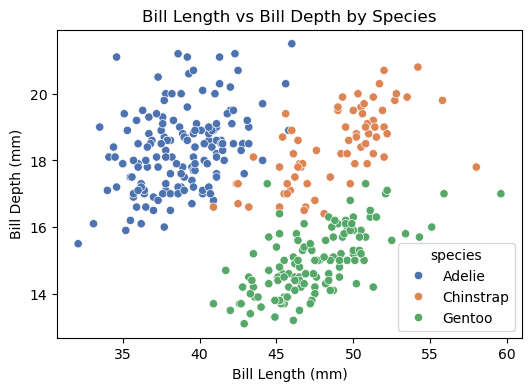

Relationship: Positive within species, distinct clusters by species.


In [27]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species', palette=['#4C72B0','#DD8452','#55A868'])
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.title('Bill Length vs Bill Depth by Species')
plt.show()
print('Relationship: Positive within species, distinct clusters by species.')

## Task 8: Line & Area Chart 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19084\2863891257.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_bin = df.groupby('bill_length_bin')['body_mass_g'].mean().reset_index()


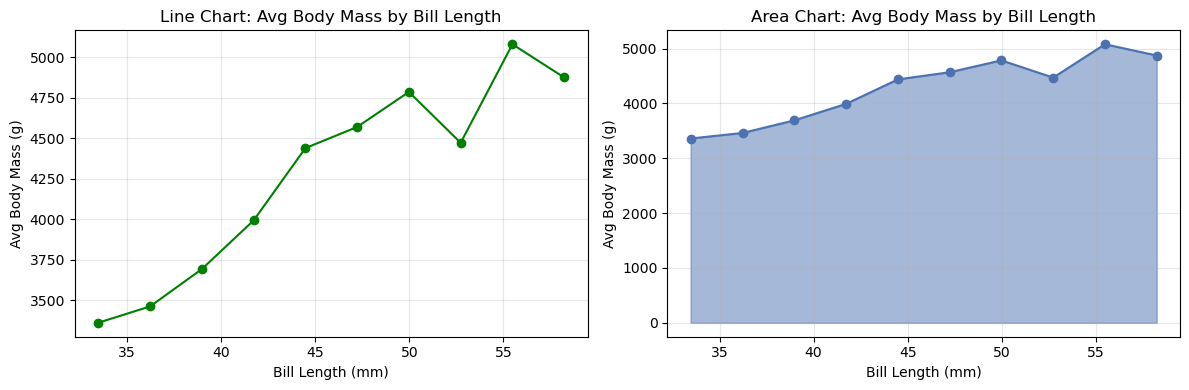

Area fill emphasizes magnitude and makes trends appear more pronounced.


In [28]:
df['bill_length_bin'] = pd.cut(df['bill_length_mm'], bins=10)
avg_by_bin = df.groupby('bill_length_bin')['body_mass_g'].mean().reset_index()
avg_by_bin['bin_center'] = avg_by_bin['bill_length_bin'].apply(lambda x: x.mid)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Line chart
axes[0].plot(avg_by_bin['bin_center'], avg_by_bin['body_mass_g'], marker='o', color='green')
axes[0].set_xlabel('Bill Length (mm)')
axes[0].set_ylabel('Avg Body Mass (g)')
axes[0].set_title('Line Chart: Avg Body Mass by Bill Length')
axes[0].grid(True, alpha=0.3)

# Area chart
axes[1].fill_between(avg_by_bin['bin_center'], avg_by_bin['body_mass_g'], alpha=0.5, color='#4C72B0')
axes[1].plot(avg_by_bin['bin_center'], avg_by_bin['body_mass_g'], marker='o', color='#4C72B0')
axes[1].set_xlabel('Bill Length (mm)')
axes[1].set_ylabel('Avg Body Mass (g)')
axes[1].set_title('Area Chart: Avg Body Mass by Bill Length')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Area fill emphasizes magnitude and makes trends appear more pronounced.')

## Task 9: Graphical Integrity Check

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19084\986258238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species', palette=['orange','blue','green'], ax=axes[0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19084\986258238.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species', palette=['orange','blue','green'], ax=axes[1])


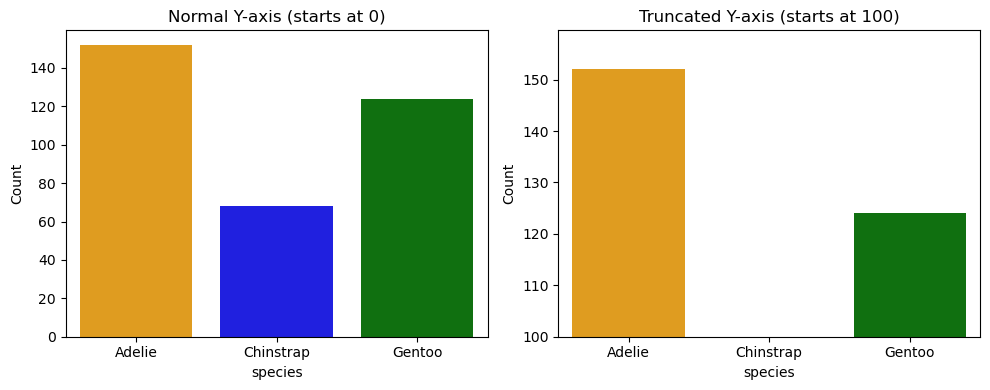

The truncated axis exaggerates differences between species counts.
Adelie appears ~2x larger than Chinstrap, but actual ratio is ~150/68 ≈ 2.2x.
Visual impression is distorted even though the data is identical.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Normal axis (starts at 0)
sns.countplot(data=df, x='species', palette=['orange','blue','green'], ax=axes[0])
axes[0].set_title('Normal Y-axis (starts at 0)')
axes[0].set_ylabel('Count')

# Truncated axis (does not start at 0)
sns.countplot(data=df, x='species', palette=['orange','blue','green'], ax=axes[1])
axes[1].set_ylim(bottom=100)
axes[1].set_title('Truncated Y-axis (starts at 100)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print('The truncated axis exaggerates differences between species counts.')
print('Adelie appears ~2x larger than Chinstrap, but actual ratio is ~150/68 ≈ 2.2x.')
print('Visual impression is distorted even though the data is identical.')